In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
secondary_df = pd.read_csv('geopolitical_conflict_risk_dataset.csv')

In [12]:
display(secondary_df.head())
secondary_df.info()

,country,region,month,political_stability_index,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,...,cyber_attack_incidents,last_conflict_year,trade_dependency_rival_pct,foreign_troops_present,election_cycle,regime_type,social_media_sentiment,rolling_protest_avg_6m,instability_score,conflict_escalation_6m
0,USA,North America,2020-01,0.496714,6.737638,5.308678,9.069739,108.263140,60.851201,2.536582,...,7,2018,22.210790,1,0,Democracy,-0.907099,2.144414,52.436131,0
1,USA,North America,2020-02,-1.150994,4.467635,7.878490,1.116625,125.221590,10.806598,1.671814,...,5,0,48.252741,0,0,Democracy,-0.457302,9.763522,98.474060,1
2,USA,North America,2020-03,-0.460639,-0.030766,11.285611,8.446705,145.774988,68.625602,2.160782,...,8,2018,31.608400,1,0,Hybrid,0.122487,6.199294,80.755509,1
3,USA,North America,2020-04,0.326845,0.155373,5.594405,7.331570,85.482074,44.383874,2.940183,...,9,2021,47.428411,0,0,Hybrid,0.389570,4.038001,58.176382,0
4,USA,North America,2020-05,0.293059,0.755706,10.483152,0.405036,111.397986,65.015718,2.672375,...,9,2018,17.123555,1,0,Hybrid,-0.663418,1.264349,60.718597,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       1320 non-null   object 
 1   region                        1320 non-null   object 
 2   month                         1320 non-null   object 
 3   political_stability_index     1320 non-null   float64
 4   gdp_growth_pct                1320 non-null   float64
 5   inflation_rate                1320 non-null   float64
 6   unemployment_rate             1320 non-null   float64
 7   food_price_index              1320 non-null   float64
 8   energy_dependency_pct         1320 non-null   float64
 9   military_expenditure_pct_gdp  1320 non-null   float64
 10  arms_imports_index            1320 non-null   float64
 11  border_disputes_count         1320 non-null   int64  
 12  refugee_outflow_thousands     1320 non-null   float64
 13  san

In [13]:
display(secondary_df.describe())

,political_stability_index,gdp_growth_pct,inflation_rate,unemployment_rate,food_price_index,energy_dependency_pct,military_expenditure_pct_gdp,arms_imports_index,border_disputes_count,refugee_outflow_thousands,...,protest_events_last_3m,cyber_attack_incidents,last_conflict_year,trade_dependency_rival_pct,foreign_troops_present,election_cycle,social_media_sentiment,rolling_protest_avg_6m,instability_score,conflict_escalation_6m
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,...,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.0,1320.000000,1320.000000,1320.000000,1320.000000
mean,0.083314,1.941791,6.411540,6.204901,120.403515,50.588338,3.014005,40.590231,2.465152,103.006721,...,4.756061,9.988636,1648.656061,26.998590,0.484091,0.0,0.045490,4.787454,66.971506,0.314394
std,0.985579,3.037963,4.120199,3.659686,25.340308,19.678890,0.990071,22.660040,1.690269,76.098756,...,3.550081,3.213980,781.440346,12.933664,0.499936,0.0,0.582049,4.022843,26.339773,0.464450
min,-2.500000,-9.509967,0.017210,0.009804,37.858345,0.112920,0.014737,0.030908,0.000000,0.134734,...,0.000000,2.000000,0.000000,5.059159,0.000000,0.0,-0.999597,-5.394958,4.014365,0.000000
25%,-0.625776,-0.172605,3.069854,3.403290,103.612126,36.753443,2.362250,23.145599,1.000000,41.823834,...,2.000000,8.000000,2014.000000,15.696271,0.000000,0.0,-0.452113,1.967803,48.202017,0.000000
50%,0.087608,1.930365,5.979951,5.933141,120.542126,50.505400,3.031139,39.300638,2.000000,89.323416,...,4.000000,10.000000,2018.000000,26.878057,0.000000,0.0,0.082981,4.342456,66.117718,0.000000
75%,0.789765,3.954005,9.116799,8.673691,136.070728,63.600030,3.701558,55.722504,4.000000,148.430830,...,7.000000,12.000000,2021.000000,37.895221,1.000000,0.0,0.570131,7.165725,84.578126,1.000000
max,2.500000,14.443685,23.144552,18.941881,202.942176,113.979604,6.687467,138.462574,5.000000,435.052233,...,21.000000,24.000000,2022.000000,49.923642,1.000000,0.0,0.997345,22.549547,149.696509,1.000000


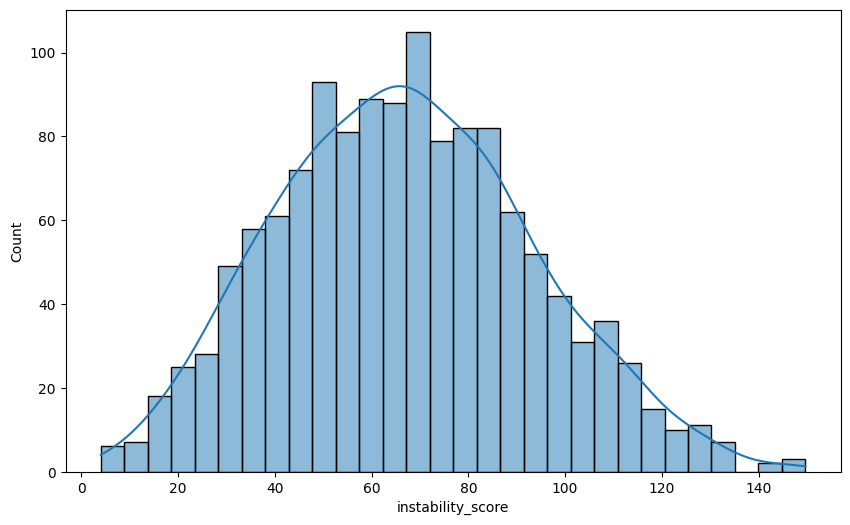

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data=secondary_df, x='instability_score', bins=30, kde=True)
plt.show()

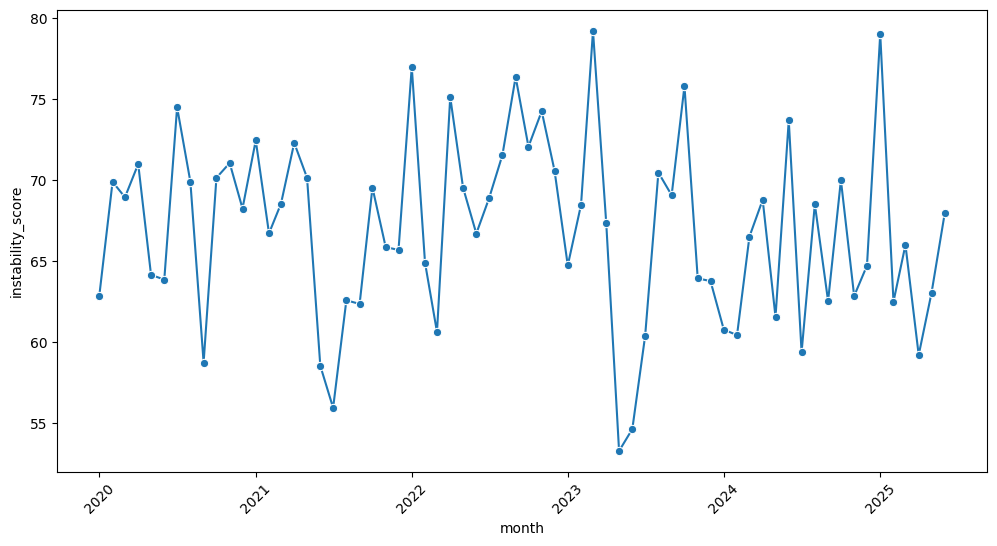

In [15]:
secondary_df['month'] = pd.to_datetime(secondary_df['month'])
global_trend = secondary_df.groupby('month')['instability_score'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=global_trend, x='month', y='instability_score', marker='o')
plt.xticks(rotation=45)
plt.show()

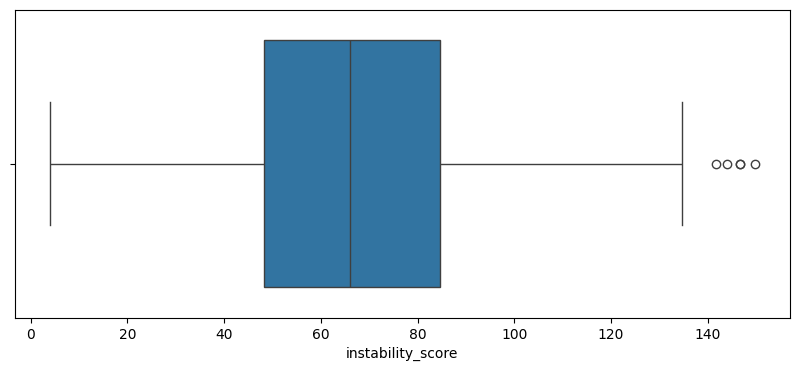

In [16]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=secondary_df, x='instability_score')
plt.show()

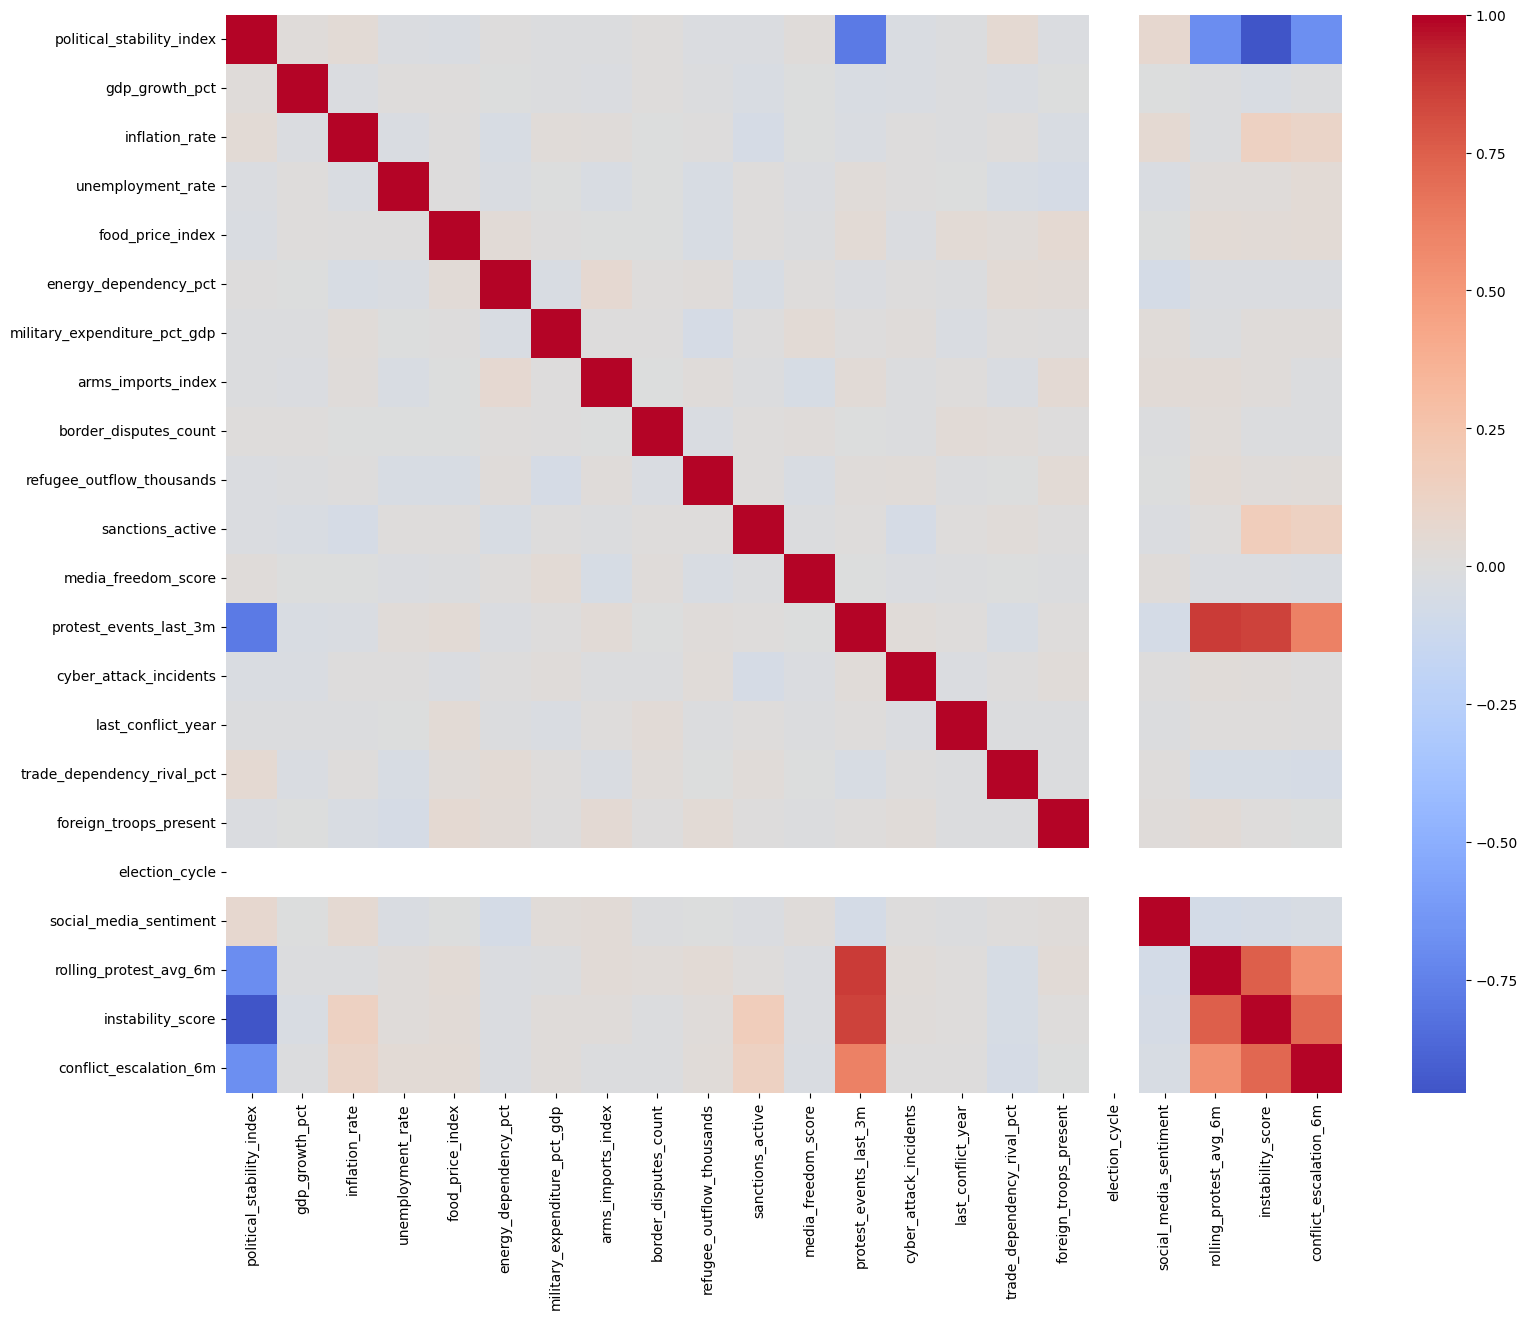

In [17]:
corr_matrix = secondary_df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix , cmap='coolwarm', center=0)
plt.show()